In [ ]:
%pip install git+https://github.com/Mishne-Lab/pyRATS
# if not already installed on the system:
# %pip install pandas imageio seaborn matplotlib

In [ ]:
from matplotlib import pyplot as plt

from pyRATS import rats
import datasets, vis

import time

matplotlib.get_backend() =  module://matplotlib_inline.backend_inline


# Load data

In [2]:
X, labels, ddX = datasets.Datasets().noisyswissroll(RES=50,noise=0.0075)

X.shape =  (2639, 3)


# Generate embeddings

In [3]:
model = rats.RATS(
    n_components=2,
    n_neighbors=28,
    min_cluster_size=5,
    tear=True,
    cost_function='alignment'
)

start = time.time()

y = model.fit_transform(X=X)

end = time.time()
y, f'runtime: {end - start}'

(array([[ 0.22311523, -0.88407409],
        [ 0.20221277, -0.88275636],
        [ 0.18213873, -0.88380495],
        ...,
        [-0.1800141 ,  0.89417296],
        [-0.19995986,  0.89646701],
        [-0.21986781,  0.89513274]], shape=(2639, 2)),
 'runtime: 5.951967000961304')

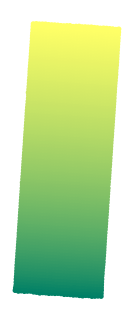

In [4]:
tear_color_eig_inds = [0, 1, 2] # interior has green color so assigned smallest value of i to g-channel
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds, 
)
vis.Visualize().global_embedding(
    y, labels[:,0],
    color_of_pts_on_tear=color_of_pts_on_tear[:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='summer',
    title='color='+str(tear_color_eig_inds),
    figsize=(3,3)
)
plt.show()